#AUTOENCODER


In [1]:
from keras.datasets import mnist
import numpy as np
import keras
from keras import layers
from IPython.utils.sysinfo import encoding

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32')/ 255.
x_test = x_test.astype('float32')/ 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 784)
(10000, 784)


In [25]:
#xay dung mo hinh autoencoder
encoding_dim = 32

input_img = keras.Input(shape=(784,))
encoder_dense = layers.Dense(encoding_dim, activation='relu')
decoder_dense = layers.Dense(784,activation='sigmoid')

input_img = keras.Input(shape=(784,))
encoded = encoder_dense(input_img)
decoded = decoder_dense(encoded)
autoencoder = keras.Model(input_img, decoded)

encoder = keras.Model(input_img, encoded)

encoded_input = keras.Input(shape=(encoding_dim,))
decoder = keras.Model(encoded_input, decoder_dense(encoded_input))

In [26]:
#huan luyen mo hinh
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256, verbose=1,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.0116 - loss: 0.2744 - val_accuracy: 0.0105 - val_loss: 0.1867
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.0116 - loss: 0.1699 - val_accuracy: 0.0109 - val_loss: 0.1534
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.0098 - loss: 0.1442 - val_accuracy: 0.0086 - val_loss: 0.1335
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0095 - loss: 0.1283 - val_accuracy: 0.0099 - val_loss: 0.1209
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0102 - loss: 0.1180 - val_accuracy: 0.0106 - val_loss: 0.1126
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.0103 - loss: 0.1109 - val_accuracy: 0.0111 - val_loss: 0.1068
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0107 - loss: 0.1058 - val_accuracy: 0.0113 - val_loss: 0.1023
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0108 - loss: 0.1020 - val_accu

In [27]:
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


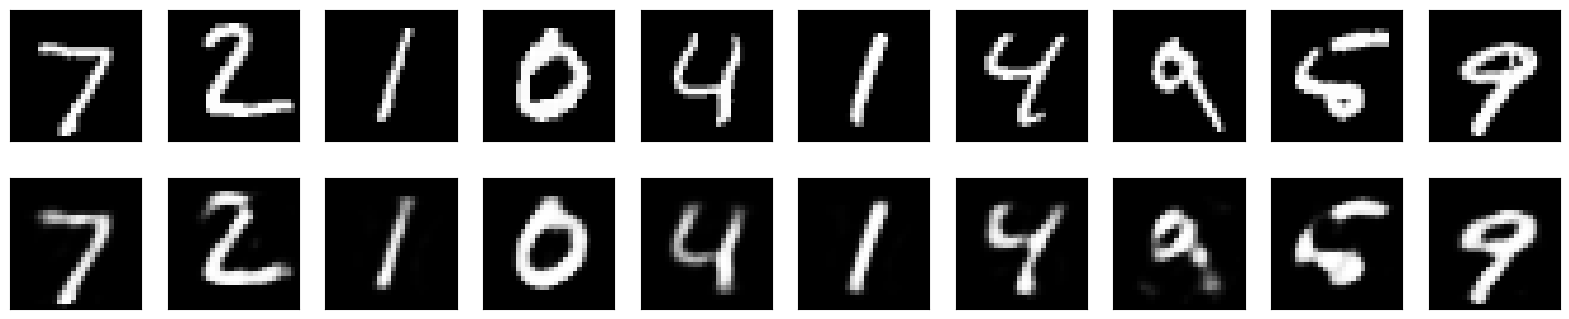

In [28]:
import matplotlib.pyplot as plt

n = 10
plt.figure(figsize=(20,4))
for i in range(n):
  ax = plt.subplot(2,n,i+1)
  plt.imshow(x_test[i].reshape(28,28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  ax = plt.subplot(2,n,i+1+n)
  plt.imshow(decoded_imgs[i].reshape(28,28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()


#CAI TIEN AUTOENCODER - THEM L1

In [16]:
from keras import regularizers
encoding_dim = 32

input_img = keras.Input(shape=(784,))
# Sử dụng tên biến riêng biệt cho layer và tensor
encoded_layer = layers.Dense(encoding_dim, activity_regularizer=regularizers.l1(1e-5), activation='relu')
encoded = encoded_layer(input_img)

decoded_layer = layers.Dense(784, activation='sigmoid')
decoded = decoded_layer(encoded)

# Định nghĩa các mô hình
autoencoder = keras.Model(input_img, decoded)
encoder = keras.Model(input_img, encoded)

encoded_input = keras.Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoded_layer(encoded_input))

In [17]:
# Sau khi chạy lại cell trên, hãy chạy cell này để huấn luyện
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256, verbose=1,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.0107 - loss: 0.4196 - val_accuracy: 0.0123 - val_loss: 0.2951
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0095 - loss: 0.2648 - val_accuracy: 0.0099 - val_loss: 0.2447
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0103 - loss: 0.2370 - val_accuracy: 0.0109 - val_loss: 0.2286
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0106 - loss: 0.2242 - val_accuracy: 0.0118 - val_loss: 0.2186
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0115 - loss: 0.2160 - val_accuracy: 0.0129 - val_loss: 0.2118
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0133 - loss: 0.2099 - val_accuracy: 0.0135 - val_loss: 0.2064
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0137 - loss: 0.2051 - val_accuracy: 0.0129 - val_loss: 0.2021
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0137 - loss: 0.2012 - val_accuracy: 0

In [18]:
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


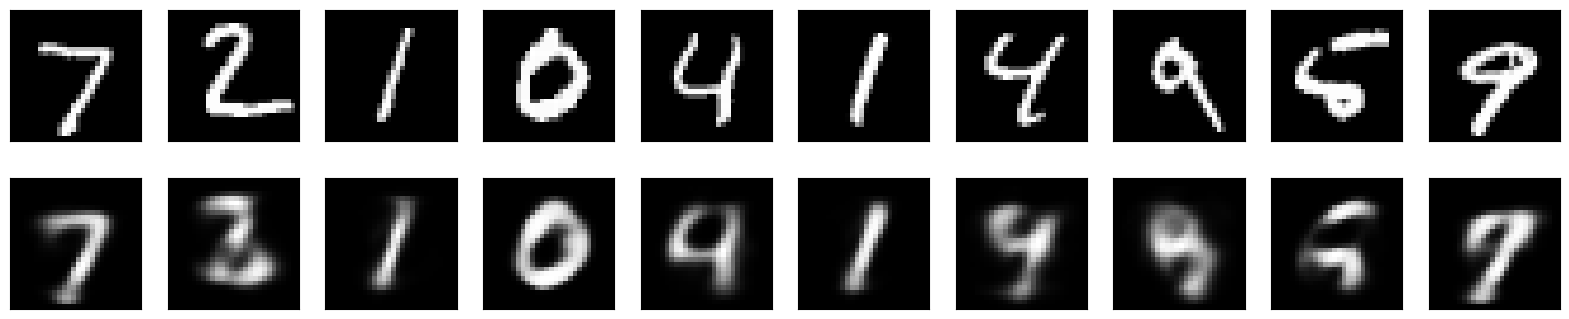

In [19]:
n = 10
plt.figure(figsize=(20,4))
for i in range(n):
  ax = plt.subplot(2,n,i+1)
  plt.imshow(x_test[i].reshape(28,28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  ax = plt.subplot(2,n,i+1+n)
  plt.imshow(decoded_imgs[i].reshape(28,28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()


#THEM LAYERS

In [3]:
encoding_dim = 32

input_img = keras.Input(shape=(784,))
# Xây dựng encoder tuần tự
x = layers.Dense(128, activation='relu')(input_img)
x = layers.Dense(64, activation='relu')(x)
encoded = layers.Dense(encoding_dim, activation='relu')(x)

# Xây dựng decoder tuần tự
x = layers.Dense(64, activation='relu')(encoded)
x = layers.Dense(128, activation='relu')(x)
decoded = layers.Dense(784, activation='sigmoid')(x)

# Khởi tạo mô hình Autoencoder tổng
autoencoder = keras.Model(input_img, decoded)

# Khởi tạo mô hình Encoder riêng
encoder = keras.Model(input_img, encoded)

# Khởi tạo mô hình Decoder riêng
encoded_input = keras.Input(shape=(encoding_dim,))
# Lấy các layer cuối của autoencoder để làm decoder
dec_x = autoencoder.layers[-3](encoded_input)
dec_x = autoencoder.layers[-2](dec_x)
dec_output = autoencoder.layers[-1](dec_x)
decoder = keras.Model(encoded_input, dec_output)

In [4]:
# Sau khi chạy lại cell , hãy chạy lại cell này để huấn luyện
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256, verbose=1,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.0107 - loss: 0.2428 - val_accuracy: 0.0134 - val_loss: 0.1631
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0095 - loss: 0.1456 - val_accuracy: 0.0092 - val_loss: 0.1325
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0083 - loss: 0.1281 - val_accuracy: 0.0131 - val_loss: 0.1213
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0110 - loss: 0.1201 - val_accuracy: 0.0114 - val_loss: 0.1157
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0114 - loss: 0.1147 - val_accuracy: 0.0119 - val_loss: 0.1110
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0120 - loss: 0.1102 - val_accuracy: 0.0119 - val_loss: 0.1069
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0114 - loss: 0.1069 - val_accuracy: 0.0107 - val_loss: 0.1056
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0118 - loss: 0.1044 - val_accuracy: 0

In [5]:
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


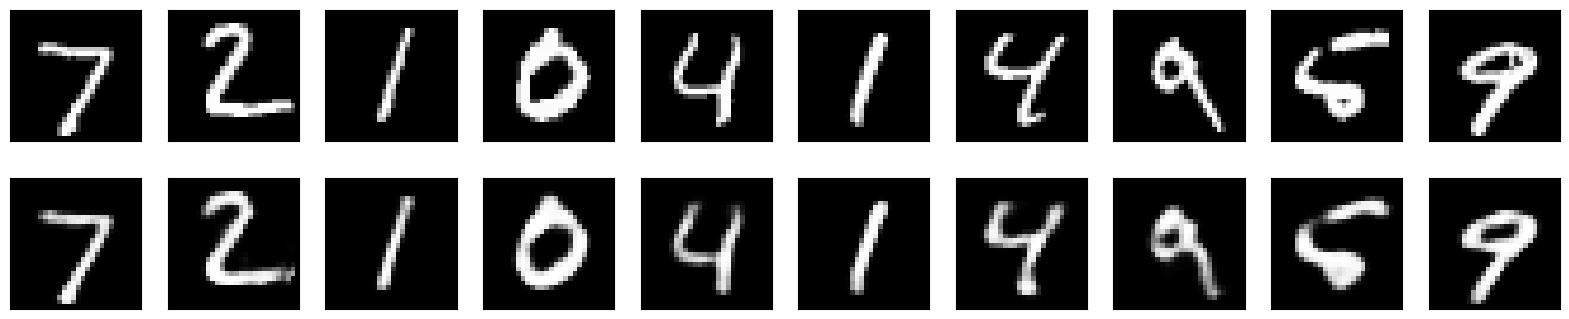

In [7]:
import matplotlib.pyplot as plt
n = 10
plt.figure(figsize=(20,4))
for i in range(n):
  ax = plt.subplot(2,n,i+1)
  plt.imshow(x_test[i].reshape(28,28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  ax = plt.subplot(2,n,i+1+n)
  plt.imshow(decoded_imgs[i].reshape(28,28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()
